<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/Copy_of_final_suspicious_activity_detection_degree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras==2.10.0
!pip install tensorflow==2.10.0
!pip install h5py==3.7.0

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip install efficientnet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!unzip /content/drive/MyDrive/suspicious_activity_detection/Data.zip -d /content/drive/MyDrive/suspicious_activity_detection

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.405.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.406.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.407.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.408.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.409.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.41.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.410.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.411.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.412.png  
  inflating: /content/drive/MyDrive/suspicious_activity_detection/Data/Fire/fire.413.png  
  inflating: /content/drive/MyDrive/susp

In [ ]:
import numpy as np
import pickle
import os
from tqdm import tqdm
import cv2
import pandas as pd
import seaborn as sns
from os import listdir
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer
from keras.models import Sequential
from sklearn.utils import shuffle
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers.core import Activation, Flatten, Dropout, Dense
from keras import backend as K
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam,SGD
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from keras.models import Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras import layers
from sklearn.metrics import classification_report,confusion_matrix
import efficientnet.keras as effnet

In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

In [ ]:
image_size=128
default_image_size = tuple((128, 128))
labels = os.listdir('/content/drive/MyDrive/suspicious_activity_detection/Data')
directory_root = '/content/drive/MyDrive/suspicious_activity_detection'
classes = len(labels)
BATCHZ_SIZE=32

In [ ]:
def image_array(dir):
    try:
        img = cv2.imread(dir)
        if img is not None :
            img = cv2.resize(img, default_image_size)
            return img_to_array(img)
        else :
            return np.array([])
    except Exception as e:
        print(f"Error : {e}")
        return None

In [ ]:
image_list, label_list = [], []

try:
    print("[INFO] Loading images ...")
    root_dir = listdir(directory_root)
    for directory in root_dir :
        # remove .DS_Store from list
        if directory == ".DS_Store" :
            root_dir.remove(directory)

    for classes_folder in root_dir :
        image_classes_folder_list = listdir(f"/content/drive/MyDrive/suspicious_activity_detection/Data/")

    for classes_folder in image_classes_folder_list :
            # remove .DS_Store from list
            if classes_folder == ".DS_Store" :
                image_classes_folder_list.remove(classes_folder)

    for  image_classes_folder in image_classes_folder_list:
            print(f"[INFO] Processing { image_classes_folder} ...")
            image_classes_image_list = listdir(f"{directory_root}/Data/{ image_classes_folder}/")

            for single_image_classes_image in image_classes_image_list :
                if single_image_classes_image == ".DS_Store" :
                    image_classes_image_list.remove(single_image_classes_image)

            for image in image_classes_image_list[:1000]:
                image_directory = f"{directory_root}/Data/{ image_classes_folder}/{image}"
                if image_directory.endswith(".jpg") == True or image_directory.endswith(".JPG") == True or image_directory.endswith(".png") == True or image_directory.endswith(".PNG") == True:
                    image_list.append(image_array(image_directory))
                    label_list.append( image_classes_folder)
    print("[INFO] Image loading completed")
except Exception as e:
    print(f"Error : {e}")

[INFO] Loading images ...
[INFO] Processing chain_snatching ...
[INFO] Processing Fight ...
[INFO] Processing Fire ...
[INFO] Processing Gun ...
[INFO] Processing Knife ...
[INFO] Processing Normal ...
[INFO] Image loading completed


In [ ]:
X = image_list
Y = label_list

In [ ]:
X = np.array(X)

In [ ]:
X, Y = shuffle(X, Y)
print(X.shape)

(4598, 128, 128, 3)


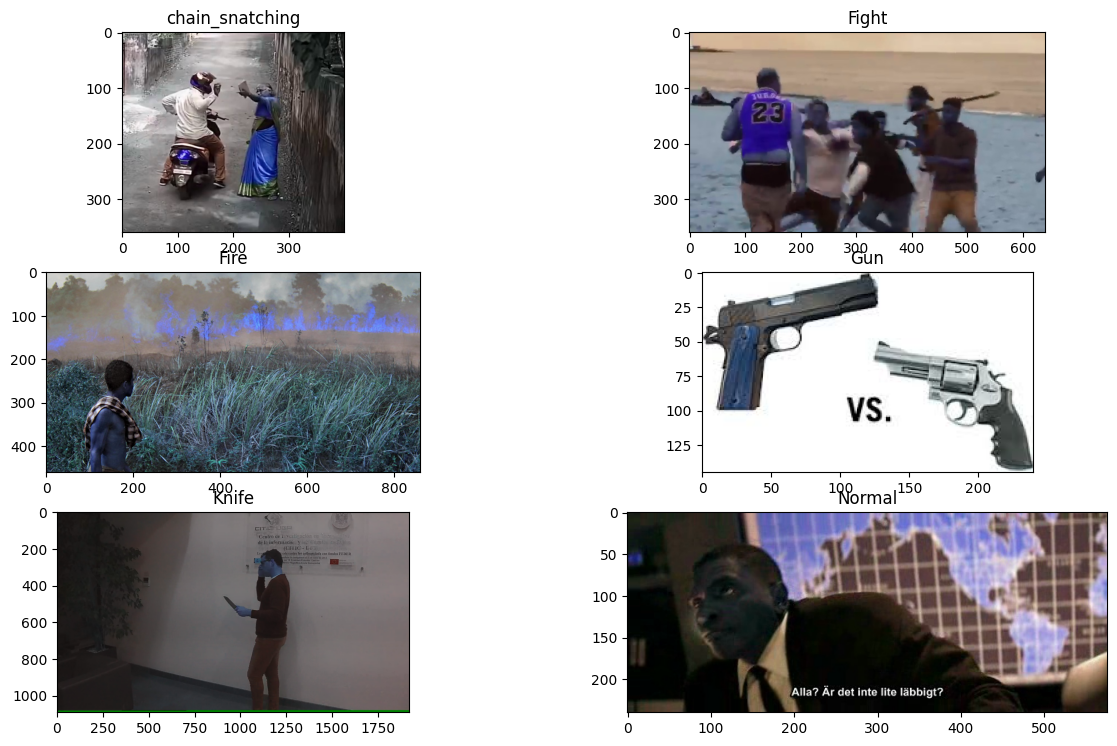

In [ ]:
#Data Visualization
import matplotlib.image as mpimg
plt.figure(figsize = (15, 40))
image_count = 1
BASE_URL = '/content/drive/MyDrive/suspicious_activity_detection/Data/'
for directory in os.listdir(BASE_URL):
    if directory[0] != '.':
        for i, file in enumerate(os.listdir(BASE_URL + directory)):
            if i == 1:
                break
            else:
                fig = plt.subplot(13, 2, image_count)
                image_count += 1
                #print(BASE_URL + directory + '/' + file)
                image = cv2.imread(BASE_URL + directory + '/' + file)
                plt.imshow(image)
                plt.title(directory)


<Axes: ylabel='count'>

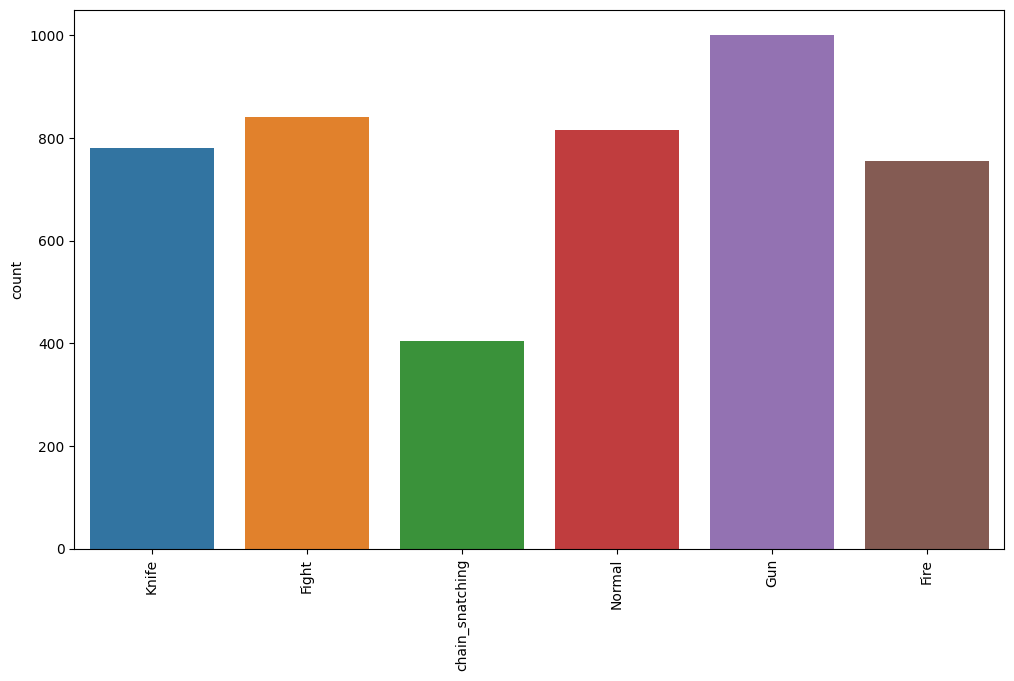

In [ ]:
#count plot
plt.figure(figsize = (12, 7))
plt.xticks(rotation=90)
sns.countplot(x=Y)

In [ ]:
class_labels = LabelBinarizer()
Y = class_labels.fit_transform(Y)
pickle.dump(class_labels,open('/content/drive/MyDrive/suspicious_activity_detection/label_transform.pkl', 'wb'))
n_classes = len(class_labels.classes_)

In [ ]:
cls = len(class_labels.classes_)
print(class_labels.classes_)

['Fight' 'Fire' 'Gun' 'Knife' 'Normal' 'chain_snatching']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1)

CNN

In [ ]:
#CNN
depth=3
model = Sequential()
inputShape = (image_size, image_size, depth)
chanDim = -1
if K.image_data_format() == "channels_first":
    inputShape = (depth, image_size, image_size)
    chanDim = 1
model.add(Conv2D(32, (3, 3), padding="same",input_shape=inputShape))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization(axis=chanDim))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(1024))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(cls))
model.add(Activation("softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 activation (Activation)     (None, 128, 128, 32)      0         
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 42, 42, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 42, 42, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 42, 42, 64)        1

In [ ]:
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.8), metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train,batch_size=BATCHZ_SIZE,validation_data=(X_val, y_val),epochs=5, verbose=1)

Epoch 1/5
117/117 [==============================] - 17s 45ms/step - loss: 7.1027 - accuracy: 0.4554 - val_loss: 6.3140 - val_accuracy: 0.3454
Epoch 2/5
117/117 [==============================] - 5s 40ms/step - loss: 1.0535 - accuracy: 0.6944 - val_loss: 79.1590 - val_accuracy: 0.1570
Epoch 3/5
117/117 [==============================] - 5s 40ms/step - loss: 0.9543 - accuracy: 0.7167 - val_loss: 0.8230 - val_accuracy: 0.7415
Epoch 4/5
117/117 [==============================] - 4s 35ms/step - loss: 0.4921 - accuracy: 0.8263 - val_loss: 0.6849 - val_accuracy: 0.7802
Epoch 5/5
117/117 [==============================] - 4s 35ms/step - loss: 0.8440 - accuracy: 0.7288 - val_loss: 2.9114 - val_accuracy: 0.3454


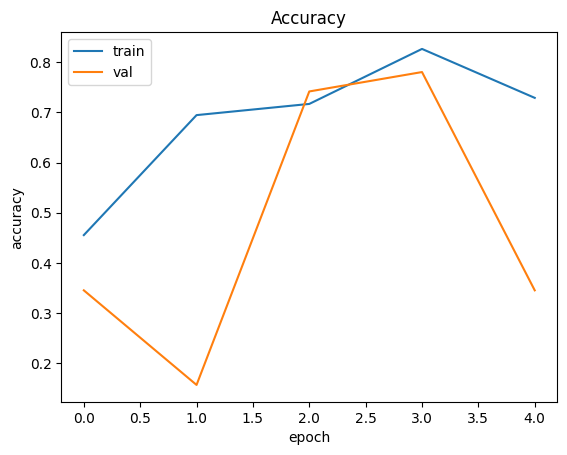

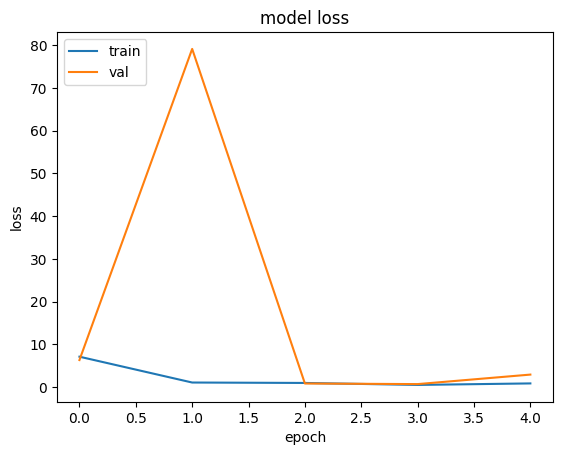

In [ ]:
#accuracy and loss plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()


#loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

In [ ]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

15/15 [==============================] - 1s 18ms/step


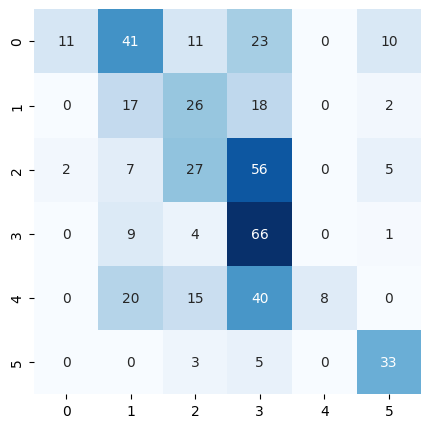

In [ ]:
cmat = confusion_matrix(y_test_new,pred)
plt.figure(figsize=(5,5))
sns.heatmap(cmat, annot = True, cbar = False, cmap='Blues', fmt="d");

In [ ]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.85      0.11      0.20        96
           1       0.18      0.27      0.22        63
           2       0.31      0.28      0.30        97
           3       0.32      0.82      0.46        80
           4       1.00      0.10      0.18        83
           5       0.65      0.80      0.72        41

    accuracy                           0.35       460
   macro avg       0.55      0.40      0.34       460
weighted avg       0.56      0.35      0.31       460



In [ ]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in range(cls):
     prec,recall,_,_ = precision_recall_fscore_support(y_test_new==l,
                                                  pred==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

pd.DataFrame(res,columns = ['class','sensitivity','specificity'])

,class,sensitivity,specificity
0,0,0.994505,0.114583
1,1,0.806045,0.269841
2,2,0.837466,0.278351
3,3,0.626316,0.825000
4,4,1.000000,0.096386
5,5,0.957041,0.804878


VGG16

In [ ]:
from keras.applications import vgg16
def build_model(backbone):
    model = Sequential()
    model.add(backbone)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(cls, activation='softmax'))


    model.compile(
        loss='categorical_crossentropy',
        optimizer='sgd',
        metrics=['accuracy']
    )

    return model

In [ ]:
vgg_model = vgg16.VGG16(weights="imagenet",
                        include_top=False,
                        input_shape=(image_size,image_size,3))

base_model = vgg16.VGG16
trainable_layers = 4

base_model = base_model(weights="imagenet", include_top=False, input_shape=(image_size,image_size,3))

for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False


model = build_model(base_model)
model.summary()

58889256/58889256 [==============================] - 1s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 batch_normalization_6 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dense_2 (Dense)             (None, 6)                 3078      
                                                       

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train,batch_size=BATCHZ_SIZE,validation_data=(X_val, y_val),epochs=5, verbose=1)

Epoch 1/5
117/117 [==============================] - 11s 75ms/step - loss: 0.4122 - accuracy: 0.8695 - val_loss: 0.1348 - val_accuracy: 0.9686
Epoch 2/5
117/117 [==============================] - 7s 56ms/step - loss: 0.1110 - accuracy: 0.9753 - val_loss: 0.1051 - val_accuracy: 0.9855
Epoch 3/5
117/117 [==============================] - 6s 54ms/step - loss: 0.0521 - accuracy: 0.9895 - val_loss: 0.0594 - val_accuracy: 0.9879
Epoch 4/5
117/117 [==============================] - 7s 57ms/step - loss: 0.0349 - accuracy: 0.9927 - val_loss: 0.0473 - val_accuracy: 0.9855
Epoch 5/5
117/117 [==============================] - 7s 59ms/step - loss: 0.0209 - accuracy: 0.9979 - val_loss: 0.0391 - val_accuracy: 0.9903


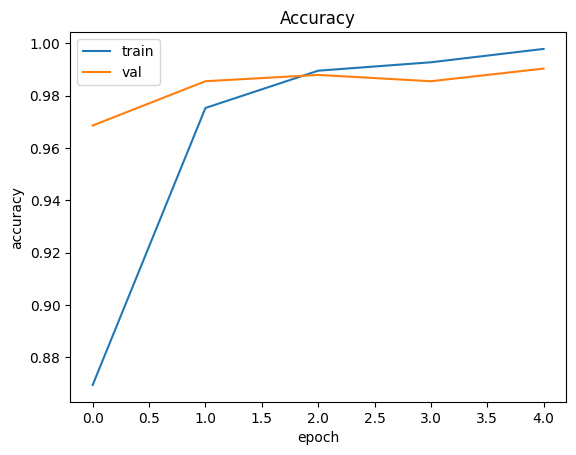

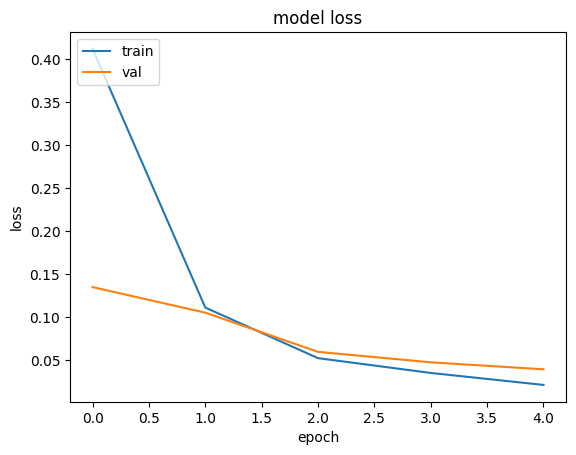

In [ ]:
#accuracy and loss plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()


#loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

In [ ]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

15/15 [==============================] - 1s 45ms/step


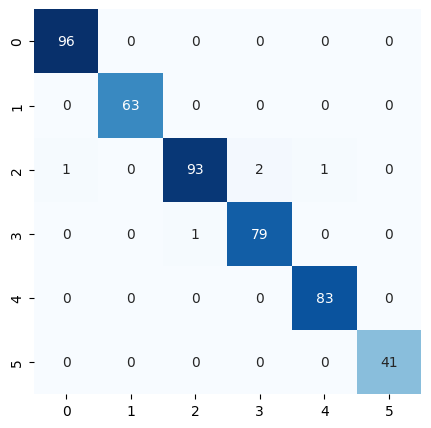

In [ ]:
cmat = confusion_matrix(y_test_new,pred)
plt.figure(figsize=(5,5))
sns.heatmap(cmat, annot = True, cbar = False, cmap='Blues', fmt="d");

In [ ]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        96
           1       1.00      1.00      1.00        63
           2       0.99      0.96      0.97        97
           3       0.98      0.99      0.98        80
           4       0.99      1.00      0.99        83
           5       1.00      1.00      1.00        41

    accuracy                           0.99       460
   macro avg       0.99      0.99      0.99       460
weighted avg       0.99      0.99      0.99       460



In [ ]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in range(cls):
     prec,recall,_,_ = precision_recall_fscore_support(y_test_new==l,
                                                  pred==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

pd.DataFrame(res,columns = ['class','sensitivity','specificity'])

,class,sensitivity,specificity
0,0,0.997253,1.000000
1,1,1.000000,1.000000
2,2,0.997245,0.958763
3,3,0.994737,0.987500
4,4,0.997347,1.000000
5,5,1.000000,1.000000


Resnet50

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

In [ ]:
resnet = ResNet50(weights= None, include_top=False, input_shape= X_train.shape[1:])

In [ ]:
x = resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(cls, activation= 'softmax')(x)
model = Model(inputs = resnet.input, outputs = predictions)

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']         

In [ ]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train,batch_size=BATCHZ_SIZE,validation_data=(X_val, y_val),epochs=5, verbose=1)

Epoch 1/5
117/117 [==============================] - 24s 144ms/step - loss: 2.0710 - accuracy: 0.4039 - val_loss: 1.6922 - val_accuracy: 0.2850
Epoch 2/5
117/117 [==============================] - 16s 138ms/step - loss: 1.0434 - accuracy: 0.6904 - val_loss: 1.9590 - val_accuracy: 0.3671
Epoch 3/5
117/117 [==============================] - 14s 124ms/step - loss: 0.6106 - accuracy: 0.8255 - val_loss: 1.6154 - val_accuracy: 0.5435
Epoch 4/5
117/117 [==============================] - 15s 125ms/step - loss: 0.5169 - accuracy: 0.8510 - val_loss: 0.8297 - val_accuracy: 0.8188
Epoch 5/5
117/117 [==============================] - 14s 123ms/step - loss: 0.3152 - accuracy: 0.9033 - val_loss: 0.3465 - val_accuracy: 0.8913


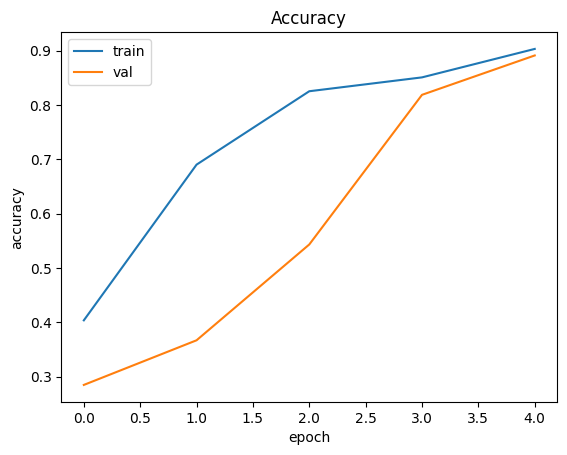

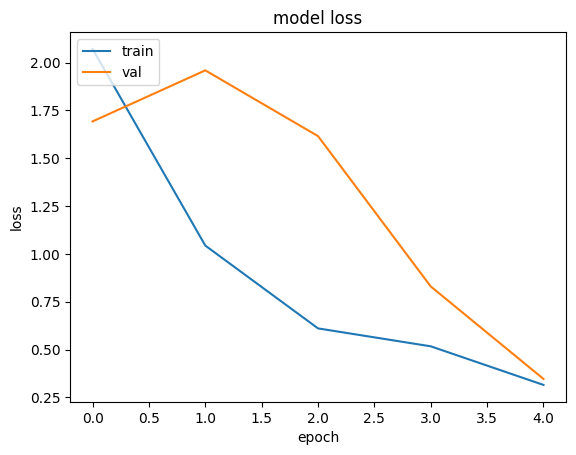

In [ ]:
#accuracy and loss plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()


#loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

In [ ]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

15/15 [==============================] - 1s 38ms/step


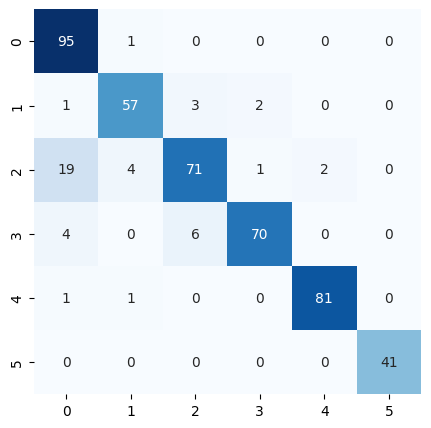

In [ ]:
cmat = confusion_matrix(y_test_new,pred)
plt.figure(figsize=(5,5))
sns.heatmap(cmat, annot = True, cbar = False, cmap='Blues', fmt="d");

In [ ]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.79      0.99      0.88        96
           1       0.90      0.90      0.90        63
           2       0.89      0.73      0.80        97
           3       0.96      0.88      0.92        80
           4       0.98      0.98      0.98        83
           5       1.00      1.00      1.00        41

    accuracy                           0.90       460
   macro avg       0.92      0.91      0.91       460
weighted avg       0.91      0.90      0.90       460



In [ ]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in range(cls):
     prec,recall,_,_ = precision_recall_fscore_support(y_test_new==l,
                                                  pred==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

pd.DataFrame(res,columns = ['class','sensitivity','specificity'])

,class,sensitivity,specificity
0,0,0.931319,0.989583
1,1,0.984887,0.904762
2,2,0.975207,0.731959
3,3,0.992105,0.875000
4,4,0.994695,0.975904
5,5,1.000000,1.000000


EfficientNetB2

In [ ]:
base_model = effnet.EfficientNetB2(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))
model = base_model.output
model = GlobalAveragePooling2D()(model)
model = Dense(cls, activation='softmax')(model)
model = Model(inputs = base_model.input, outputs=model)

31936256/31936256 [==============================] - 0s 0us/step


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv (Conv2D)             (None, 64, 64, 32)   864         ['input_4[0][0]']                
                                                                                                  
 stem_bn (BatchNormalization)   (None, 64, 64, 32)   128         ['stem_conv[0][0]']              
                                                                                                  
 stem_activation (Activation)   (None, 64, 64, 32)   0           ['stem_bn[0][0]']          

In [ ]:
history = model.fit(X_train, y_train,batch_size=BATCHZ_SIZE,validation_data=(X_val, y_val),epochs=5, verbose=1)

Epoch 1/5
117/117 [==============================] - 42s 223ms/step - loss: 0.2205 - accuracy: 0.9369 - val_loss: 0.2034 - val_accuracy: 0.9444
Epoch 2/5
117/117 [==============================] - 18s 158ms/step - loss: 0.0775 - accuracy: 0.9780 - val_loss: 0.0424 - val_accuracy: 0.9928
Epoch 3/5
117/117 [==============================] - 18s 153ms/step - loss: 0.0511 - accuracy: 0.9844 - val_loss: 0.0506 - val_accuracy: 0.9831
Epoch 4/5
117/117 [==============================] - 18s 151ms/step - loss: 0.0632 - accuracy: 0.9815 - val_loss: 1.2275 - val_accuracy: 0.8744
Epoch 5/5
117/117 [==============================] - 18s 151ms/step - loss: 0.0704 - accuracy: 0.9809 - val_loss: 0.0486 - val_accuracy: 0.9903


In [ ]:
#model.save('/content/drive/MyDrive/suspicious_activity_detection/Models/EfficientnetB2.h5')

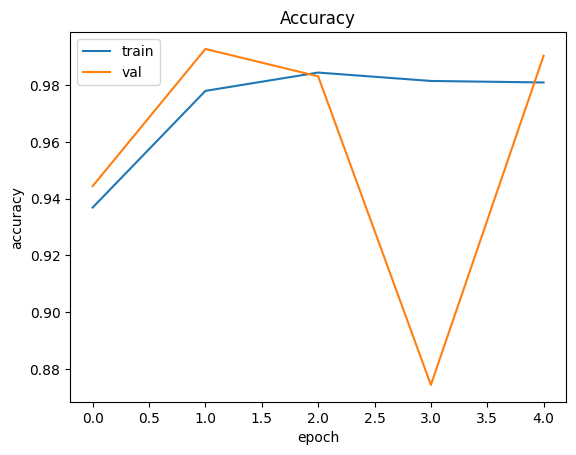

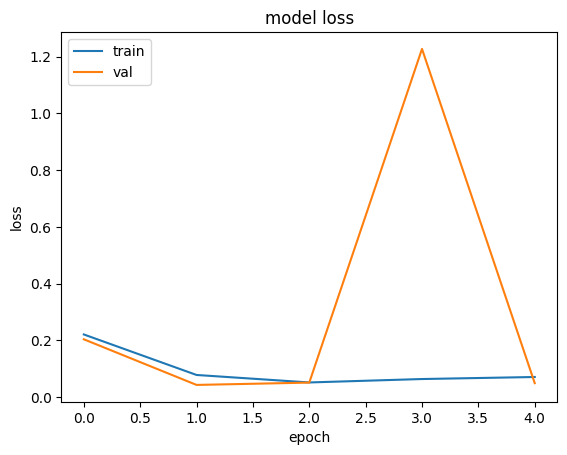

In [ ]:
#accuracy and loss plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()


#loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

In [ ]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

15/15 [==============================] - 2s 34ms/step


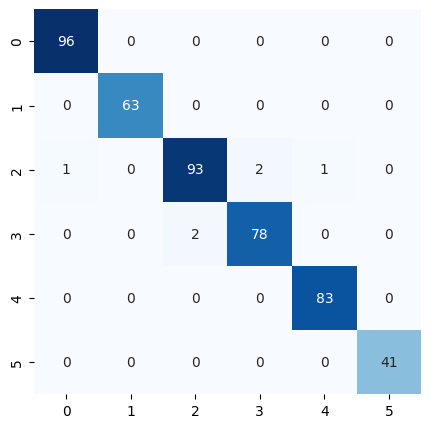

In [ ]:
cmat = confusion_matrix(y_test_new,pred)
plt.figure(figsize=(5,5))
sns.heatmap(cmat, annot = True, cbar = False, cmap='Blues', fmt="d");

In [ ]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        96
           1       1.00      1.00      1.00        63
           2       0.98      0.96      0.97        97
           3       0.97      0.97      0.97        80
           4       0.99      1.00      0.99        83
           5       1.00      1.00      1.00        41

    accuracy                           0.99       460
   macro avg       0.99      0.99      0.99       460
weighted avg       0.99      0.99      0.99       460



In [ ]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in range(cls):
     prec,recall,_,_ = precision_recall_fscore_support(y_test_new==l,
                                                  pred==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

pd.DataFrame(res,columns = ['class','sensitivity','specificity'])

,class,sensitivity,specificity
0,0,0.997253,1.000000
1,1,1.000000,1.000000
2,2,0.994490,0.958763
3,3,0.994737,0.975000
4,4,0.997347,1.000000
5,5,1.000000,1.000000


Testing

In [ ]:
class_labels = pd.read_pickle(r'/content/drive/MyDrive/suspicious_activity_detection/label_transform.pkl')
label = class_labels.classes_.tolist()
label

['Fight', 'Fire', 'Gun', 'Knife', 'Normal', 'chain_snatching']

In [ ]:
filepath = '/content/drive/MyDrive/suspicious_activity_detection/Data/Gun/armas (1).jpg'
image = cv2.imread(filepath)
image = img_to_array(image)
image = cv2.resize(image, (image_size, image_size))
image = np.array([image])

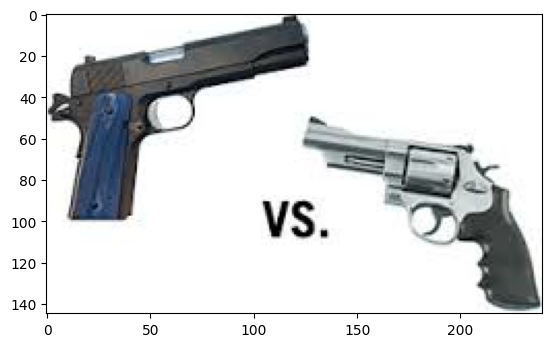

In [ ]:
imgvz = cv2.imread(filepath)
plt.imshow(imgvz)

In [ ]:
image.shape

(1, 128, 128, 3)

In [ ]:
model =load_model('/content/drive/MyDrive/suspicious_activity_detection/Models/EfficientnetB2.h5')
prediction=model.predict(image)
print(prediction)
print(max(prediction[0]))

1/1 [==============================] - 3s 3s/step
[[7.3751560e-12 5.6769597e-15 1.0000000e+00 2.1977924e-21 1.5635851e-19
  4.3707889e-18]]
1.0


In [ ]:
pred_= prediction[0]
pred=[]
for ele in pred_:
  pred.append(ele)

In [ ]:
maxi_ele = max(pred)
idx = pred.index(maxi_ele)
final_class=label
class_name= final_class[idx]
print("Predicted Class Is : " + str(class_name))

Predicted Class Is : Gun
